# Phase diagram parameter scans for KPZ regime

In [1]:
import numpy as np
import pandas as pd
import os

from surface_functions_2D import compute_surface_variance, compute_surface_roughness

## Dataframe computations

In [2]:
summary_rows = []
for typescan in ["HORIZ"]:

    for tandelta in ["5"]:
        
        path = f"{typescan}/all_simulations_delta{tandelta}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue
    
        # Load previously saved simulations
        df = pd.read_pickle(path)
    
        roughness_list = []  # used to compute per-sim roughness
        variance_list = []   # used to compute per-sim variance
        datapoint_list = []
    
        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]
    
            # ensure array, not list-of-lists
            variance = np.asarray(compute_surface_variance(phases), dtype=float)
            roughness = np.asarray(compute_surface_roughness(phases), dtype=float)
    
            variance_list.append(variance)
            roughness_list.append(roughness)
            datapoint_list.append(len(roughness))
    
        # Avoid chained-assignment issues
        df = df.copy()
        df["variance"] = variance_list
        df["roughness"] = roughness_list
        df["datapoints"] = datapoint_list
    
        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)
    
        ## AVERAGE ROUGHNESS PER (K, L, T) ##
        # group by K, L, T and compute mean roughness for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):

            rough_arrays = [np.asarray(r, dtype=float) for r in group["roughness"]]
            mean_roughness = np.mean(np.stack(rough_arrays, axis=0), axis=0)
    
            # assume all t are identical within group; take the first
            t = group.iloc[0]["t"]
            seed_list = group.index.tolist()
            M = len(seed_list) 
    
            avg_id = f"L{L_val}_K{K_val}_T{T_val}_tandelta{tandelta}_M{M}"
            print(avg_id)
    
            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "tandelta": tandelta,
                    "K": K_val,
                    "L": L_val,
                    "t": t,
                    "M": M,
                    "T": T_val,
                    "mean_roughness": mean_roughness,
                }
            )

L125_K1.0_T20000_tandelta5_M45
L250_K1.0_T20000_tandelta5_M45
L125_K1.2_T20000_tandelta5_M45
L250_K1.2_T20000_tandelta5_M27
L125_K1.4_T20000_tandelta5_M45
L125_K1.6_T20000_tandelta5_M45
L125_K1.8_T20000_tandelta5_M45
L125_K2.0_T20000_tandelta5_M45
L125_K2.2_T20000_tandelta5_M45
L125_K2.4000000000000004_T20000_tandelta5_M29


In [3]:
# Note: we start from scratch the average DataFrame (each time this code is run)
avg_df = pd.DataFrame()
avg_df_path = "average_simulations_horiz.pkl"

# Build/update AverageSims dataframe
if summary_rows:
    new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
    if avg_df.empty:
        avg_df = new_avg
    else:
        # ensure we have an index; if not, give it one
        if avg_df.index.name is None:
            avg_df = avg_df.copy()
            avg_df.index.name = "avg_id"
        avg_df = pd.concat([avg_df, new_avg])
        # keep last occurrence per avg_id
        avg_df = avg_df[~avg_df.index.duplicated(keep="last")]

    avg_df.to_pickle(avg_df_path)
    print(f"Saved average simulations ({len(df)}) to:", avg_df_path)

Saved average simulations (416) to: average_simulations_horiz.pkl


In [4]:
avg_df

,tandelta,K,L,t,M,T,mean_roughness
avg_id,,,,,,,
L125_K1.0_T20000_tandelta5_M45,5,1.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",45,20000,"[0.0, 0.07439656161020841, 0.08345274118919287..."
L250_K1.0_T20000_tandelta5_M45,5,1.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",45,20000,"[0.0, 0.07445228785430313, 0.08348032849705941..."
L125_K1.2_T20000_tandelta5_M45,5,1.2,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",45,20000,"[0.0, 0.07118419593798127, 0.07905309346133607..."
L250_K1.2_T20000_tandelta5_M27,5,1.2,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",27,20000,"[0.0, 0.07114492876287784, 0.07907339819831392..."
L125_K1.4_T20000_tandelta5_M45,5,1.4,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",45,20000,"[0.0, 0.06823294058004539, 0.0751925321259931,..."
L125_K1.6_T20000_tandelta5_M45,5,1.6,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",45,20000,"[0.0, 0.06570330912761074, 0.07187468899223806..."
L125_K1.8_T20000_tandelta5_M45,5,1.8,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",45,20000,"[0.0, 0.0633931865967599, 0.0688245812443084, ..."
L125_K2.0_T20000_tandelta5_M45,5,2.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",45,20000,"[0.0, 0.06132250280147178, 0.06637348367885007..."
L125_K2.2_T20000_tandelta5_M45,5,2.2,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",45,20000,"[0.0, 0.05946031838690028, 0.06408266700673676..."


In [5]:
avg_df.describe()

,K,L,M,T
count,10.000000,10.000000,10.000000,10.0
mean,1.580000,150.000000,41.600000,20000.0
std,0.502881,52.704628,7.183314,0.0
min,1.000000,125.000000,27.000000,20000.0
25%,1.200000,125.000000,45.000000,20000.0
50%,1.500000,125.000000,45.000000,20000.0
75%,1.950000,125.000000,45.000000,20000.0
max,2.400000,250.000000,45.000000,20000.0


## Inspection of the computed quantities

In [6]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

%load_ext autoreload
%autoreload 2

from plotting_helpers_evolution import plot_roughness_evolution
# from plotting_helpers_collapse import plot_roughness_collapse

In [7]:
avg_df_path = "average_simulations_horiz.pkl"
avg_df = pd.read_pickle(avg_df_path)

In [8]:
T = 20000

In [9]:
t = avg_df["t"].iloc[0] # Careful! Here I assume every simulation has the same t...
ts=[(1,2), (9,10), (-2,-1)] # Beginning, halfway, end

In [10]:
markerdict = {125: "^", 250: "x", 500: "o", 1000: "s"}

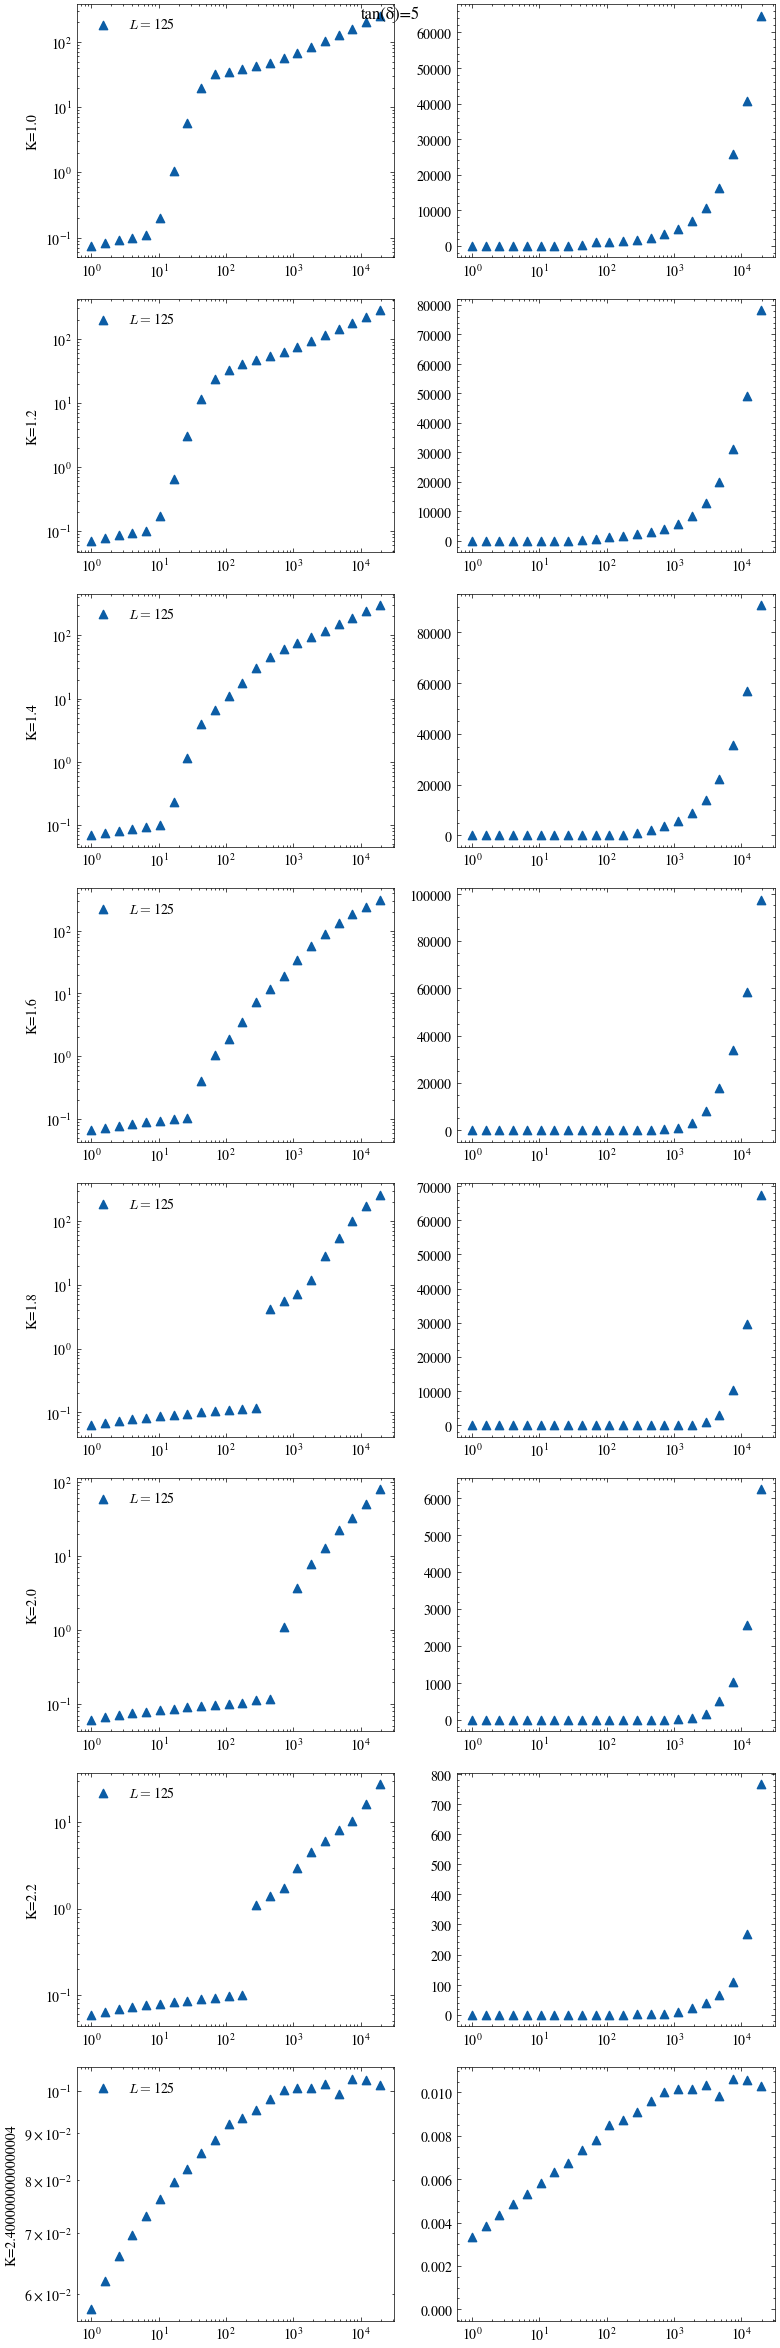

In [21]:
listKs = avg_df["K"].unique()

fig, ax = plt.subplots(len(listKs),2, figsize=(8,3*len(listKs)))
fig.suptitle(fr"tan(δ)={tandelta}")


for i, Ki in enumerate(listKs):

    for _, single_case in avg_df[avg_df["K"] == Ki].iterrows():
        
        tandelta = single_case["tandelta"]
        K = single_case["K"]
        L = single_case["L"]
        t = single_case["t"]
        W = single_case["mean_roughness"]

        if L != 125:
            continue
        
        ax[i,0].scatter(t, W, label=r"$L=$" + str(L), marker=markerdict[L])
        ax[i,1].scatter(t, W**2, label=r"$L=$" + str(L), marker=markerdict[L])
        ax[i,0].set_xscale('log')
        ax[i,0].set_yscale('log')
        ax[i,1].set_xscale('log')

    ax[i,0].set_ylabel(f"K={K}")
    ax[i,0].legend()

plt.tight_layout()
plt.savefig("Figures/Horizontal_1.0-3.1.png", dpi=300)

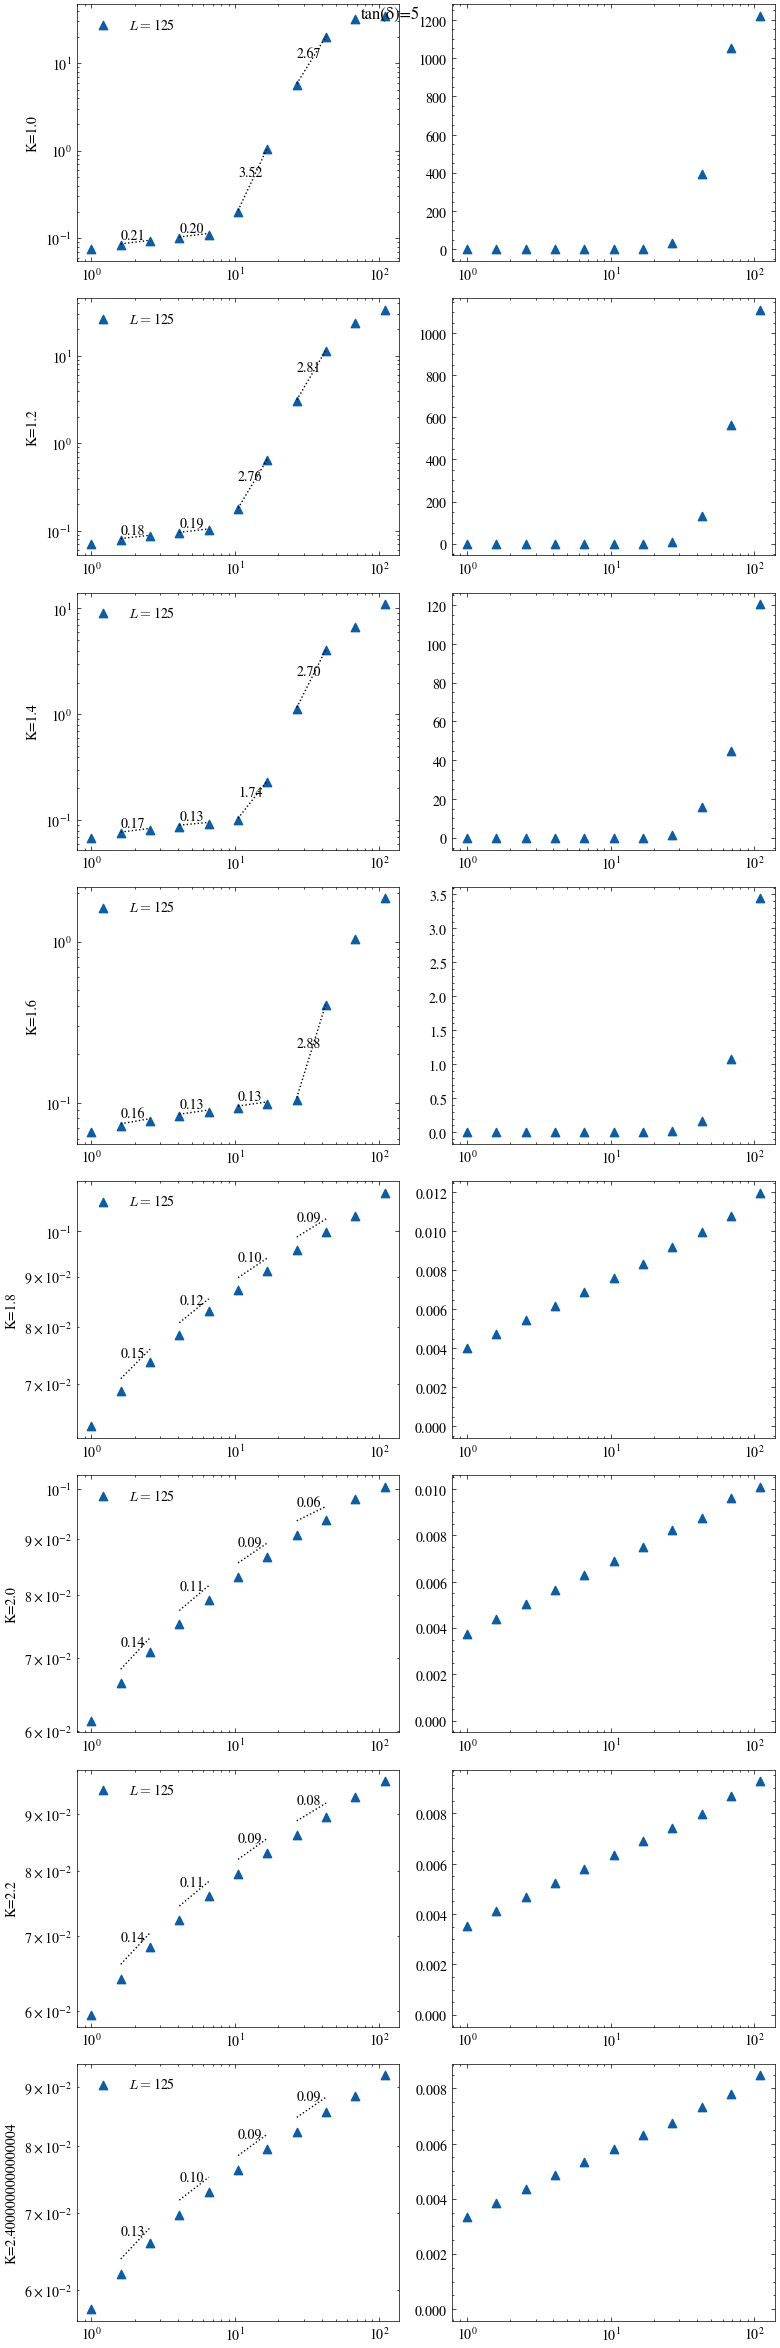

In [20]:
listKs = avg_df["K"].unique()

fig, ax = plt.subplots(len(listKs),2, figsize=(8,3*len(listKs)))
fig.suptitle(fr"tan(δ)={tandelta}")

ns = 12
for i, Ki in enumerate(listKs):

    for _, single_case in avg_df[avg_df["K"] == Ki].iterrows():
        
        tandelta = single_case["tandelta"]
        K = single_case["K"]
        L = single_case["L"]
        t = single_case["t"]
        W = single_case["mean_roughness"]

        if L != 125:
            continue
        
        ax[i,0].scatter(t[:ns], W[:ns], label=r"$L=$" + str(L), marker=markerdict[L])
        ax[i,1].scatter(t[:ns], (W**2)[:ns], label=r"$L=$" + str(L), marker=markerdict[L])
        ax[i,0].set_xscale('log')
        ax[i,0].set_yscale('log')
        ax[i,1].set_xscale('log')
    
        for tsi in [(2,3),(4,5),(6,7),(8,9)]:
            
            if L != 125:
                continue
            
            # Extract coordinates (move Y up a bit)
            x1, x2 = t[tsi[0]], t[tsi[1]]
            y1, y2 = W[tsi[0]]*1.03, W[tsi[1]]*1.03
            
            # Calculate log-log slope
            slope = (np.log10(y2) - np.log10(y1)) / (np.log10(x2) - np.log10(x1))
            
            # Plotting
            ax[i,0].loglog([x1, x2], [y1, y2], 'k:', lw=1) # Slope line
            
            # Text placement (midpoint in log-space)
            ax[i,0].text(np.sqrt(x1*x2)*0.96, np.sqrt(y1*y2)*1.01, f'{slope:.2f}', color='k', ha='center', va='bottom')
    
    ax[i,0].set_ylabel(f"K={K}")
    ax[i,0].legend()

plt.tight_layout()
# plt.savefig("Figures/Horizontal_1.0-3.1.png", dpi=300)

#### Single out one

125


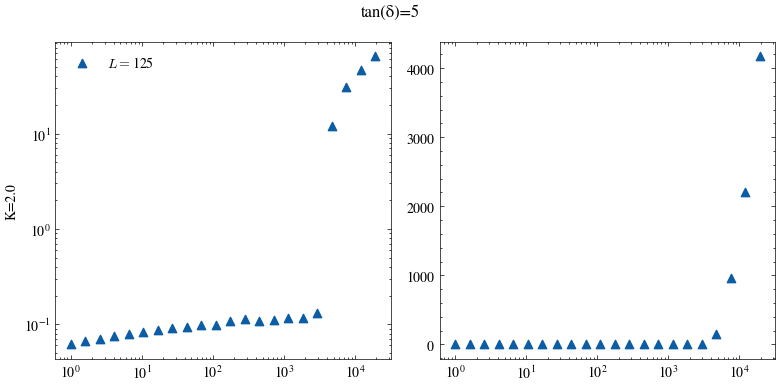

In [44]:
fig, ax = plt.subplots(1,2, figsize=(8,4))
fig.suptitle(fr"tan(δ)={tandelta}")

for _, single_case in avg_df[(avg_df["K"] == 2.0) & (avg_df["L"] == 125)].iterrows():
    
    tandelta = single_case["tandelta"]
    K = single_case["K"]
    L = single_case["L"]
    t = single_case["t"]
    W = single_case["mean_roughness"]
    
    print(L)

ax[0].scatter(t, W, label=r"$L=$" + str(L), marker=markerdict[L])
ax[1].scatter(t, W**2, label=r"$L=$" + str(L), marker=markerdict[L])
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_xscale('log')

ax[0].set_ylabel(f"K={K}")
ax[0].legend()

plt.tight_layout()

125


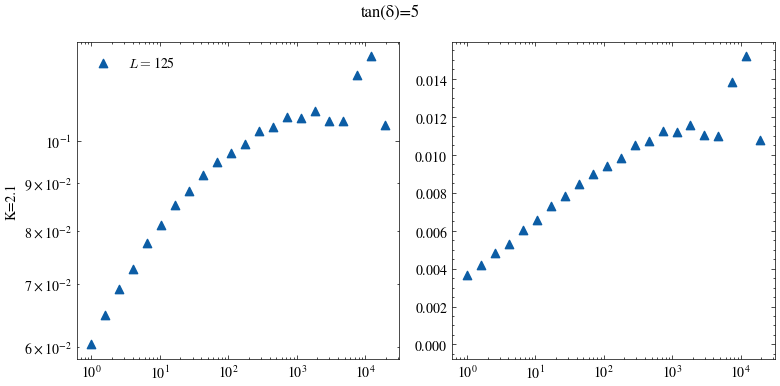

In [43]:
fig, ax = plt.subplots(1,2, figsize=(8,4))
fig.suptitle(fr"tan(δ)={tandelta}")

for _, single_case in avg_df[(avg_df["K"] == 2.1) & (avg_df["L"] == 125)].iterrows():
    
    tandelta = single_case["tandelta"]
    K = single_case["K"]
    L = single_case["L"]
    t = single_case["t"]
    W = single_case["mean_roughness"]
    
    print(L)

ax[0].scatter(t, W, label=r"$L=$" + str(L), marker=markerdict[L])
ax[1].scatter(t, W**2, label=r"$L=$" + str(L), marker=markerdict[L])
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_xscale('log')

ax[0].set_ylabel(f"K={K}")
ax[0].legend()

plt.tight_layout()

In [20]:
avg_df.iloc[0]

tandeltai                                                       5.0
K                                                              10.0
L                                                               125
t                 [0.0, 1.00000050000025, 1.6000008000004002, 2....
M                                                                 5
T                                                             20000
mean_roughness    [0.0, 0.03365536464719645, 0.03518953952244774...
Name: L125_K10.0_T20000_tandelta5.0_M5, dtype: object

In [19]:
print(f"Times: start {(np.round([t[1],t[2]],1))}, medium {np.round([t[9],t[10]],1)}, final {np.round([t[-2],t[-1]],1)}") 
print()

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
):
    print("#", typenoise)
    for j, (delta, deltaname, nameeq) in enumerate(zip([0, np.arctan(10)], ["0", "atan10"], ["EW","KPZ"])):

        print("##", nameeq, "( δ =",deltaname,")")
        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & (avg_df["T"] == T)
            & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            # & (avg_df["L"] < 1000)
        )
        sub_df = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub_df.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]
            L = row["L"]
            K = row["K"]
        
            if L == 500:
                print("-- loglog Slopes --")
                slope_initial = np.log(mean_roughness[2]) - np.log(mean_roughness[1])
                slope_initial /= (np.log(t[2]) - np.log(t[1]))
                slope_medium = np.log(mean_roughness[10]) - np.log(mean_roughness[9])
                slope_medium /= (np.log(t[10]) - np.log(t[9]))
                slope_final = np.log(mean_roughness[-2]) - np.log(mean_roughness[-1])
                slope_final /= (np.log(t[-2]) - np.log(t[-1]))
                print("β =",np.round(slope_initial,2), np.round(slope_medium,2), np.round(slope_final,2))
                print()
                    

Times: start [1.  1.6], medium [42.9 68.7], final [12089.3 19342.8]

# TimeDep
## EW ( δ = 0 )
## KPZ ( δ = atan10 )
-- loglog Slopes --
β = 0.25 0.31 0.5

# Columnar
## EW ( δ = 0 )
-- loglog Slopes --
β = 0.01 0.25 0.62

## KPZ ( δ = atan10 )
-- loglog Slopes --
β = 0.54 0.81 0.0



# TimeDep
## 0
## atan10
# Columnar
## 0
## atan10


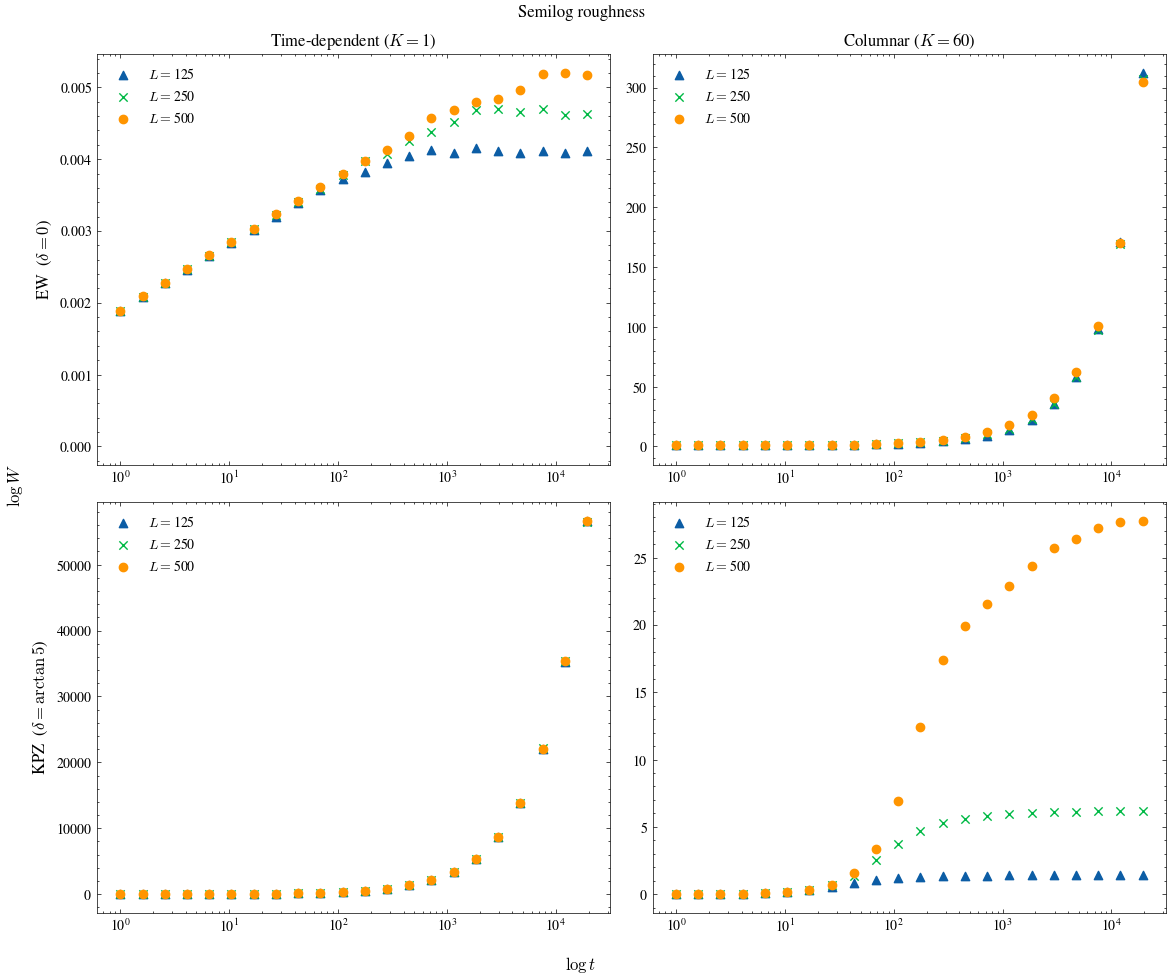

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(12,10))
fig.suptitle("Semilog roughness")

fig.supxlabel(r"$\log t$")
fig.supylabel(r"$\log W$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
):
    print("#", typenoise)
    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(10)], ["0", "atan10"])):

        print("##", deltaname)
        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & (avg_df["T"] == T)
            & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            & (avg_df["L"] < 1000)
        )
        sub_df = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub_df.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]
            L = row["L"]
            K = row["K"]
                    
            ax[j,i].scatter(t, mean_roughness**2, label=r"$L=$" + str(L), marker=markerdict[L])

        ax[j,i].set_xscale('log')
        # ax[j,i].set_yscale('log')
        
    # Scalings
    #ax[0,0].semilogx(t[1:-5:], 0.0022 + np.log(t[1:-5:])/2600, linestyle="--", color="k")

ax[0,0].set_title(f"Time-dependent ($K=${Ks[0]})")
ax[0,1].set_title(f"Columnar ($K=${Ks[1]})")      
ax[0,0].set_ylabel(r"EW  ($\delta=0$)", fontsize=12)
ax[1,0].set_ylabel(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.tight_layout()
# plt.show()

plt.savefig("Figures/Evolution/atan10-sqrtlog1-60.png")

In [15]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.4}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 1, "KPZ": 0.96}} # anomalous scaling, only for columnar noise
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": 0.34, "KPZ": 0.93}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

#### Family-Vicsek collapse

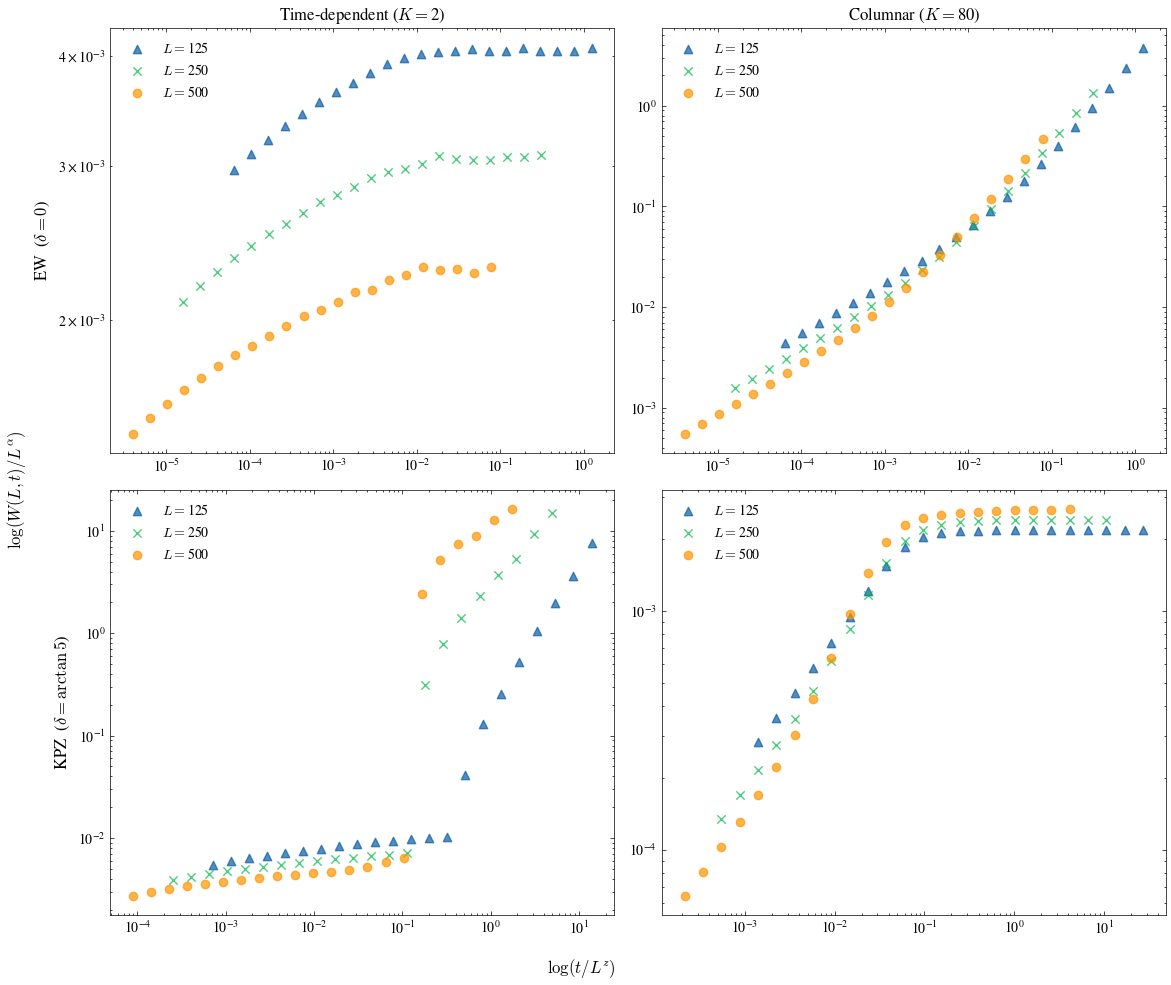

In [28]:
plot_roughness_collapse(avg_df, T, tx, Ks=Ks)

### Small coupling in time dependent, KPZ

Can be observed for $K=1$ and $2$ (with the latter having a more persistent KPZ behavior).

In [42]:
typenoise = "TimeDep"
typelabel = "Time-dependent noise"
deltaname = "atan5"

markerdict = {125: "^", 250: "x", 500: "o", 1000: "s"}

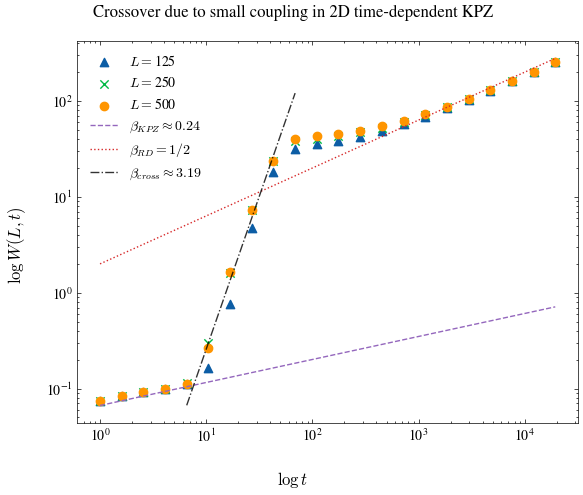

In [73]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
fig.suptitle("Crossover due to small coupling in 2D time-dependent KPZ")

fig.supxlabel(r"$\log t$")
fig.supylabel(r"$\log W(L,t)$")

# select rows for this noise type and delta
mask = mask = (
    (avg_df["typenoise"] == typenoise)
    & (avg_df["deltaname"] == deltaname)
    & (avg_df["T"] == T)
    & (avg_df["K"] == 1)
    & (avg_df["L"] < 1000)
)
sub_df = avg_df[mask]

# in case there are multiple (K, L) combos, plot them all
for _, row in sub_df.iterrows():
    t = row["t"]
    mean_roughness = row["mean_roughness"]
    L = row["L"]
    K = row["K"]                    
    
    ax.scatter(t, mean_roughness, label=r"$L=$" + str(L), marker=markerdict[L])

ax.set_xscale('log')
ax.set_yscale('log')

# Scalings
ax.loglog(t[1:], t[1:]**(0.24) /15, label=r"$\beta_{KPZ} \approx 0.24$", linestyle="--", color="tab:purple", alpha=1)
ax.loglog(t[1:], t[1:]**(0.5) * 2, label=r"$\beta_{RD} = 1/2$", linestyle=":", color="tab:red", alpha=1)
ax.loglog(t[5:11], t[5:11]**(3.19) /6000, label=r"$\beta_{cross} \approx 3.19$", linestyle="dashdot", color="k", alpha=0.8)

ax.legend()

plt.tight_layout()
plt.show()

In [74]:
(t[1],t[2]),(t[7],t[8]),(t[-2],t[-1])

((np.float64(1.00000050000025), np.float64(1.6000008000004002)),
 (np.float64(16.770008385004193), np.float64(26.840013420006713)),
 (np.float64(12089.256044628024), np.float64(19342.819671409838)))

In [75]:
# select rows for this noise type and delta
mask = mask = (
    (avg_df["typenoise"] == typenoise)
    & (avg_df["deltaname"] == deltaname)
    & (avg_df["T"] == T)
    & (avg_df["K"] == 1)
    # & (avg_df["L"] < 1000)
)
sub_df = avg_df[mask]

# in case there are multiple (K, L) combos, plot them all
for _, row in sub_df.iterrows():
    t = row["t"]
    mean_roughness = row["mean_roughness"]
    L = row["L"]
    K = row["K"]

    if L == 500:
        print("#", typenoise)
        print("##", nameeq, "( δ =",deltaname,")")
        print("-- loglog Slopes --")
        slope_initial = np.log(mean_roughness[2]) - np.log(mean_roughness[1])
        slope_initial /= (np.log(t[2]) - np.log(t[1]))
        slope_medium = np.log(mean_roughness[7]) - np.log(mean_roughness[8])
        slope_medium /= (np.log(t[7]) - np.log(t[8]))
        slope_final = np.log(mean_roughness[-2]) - np.log(mean_roughness[-1])
        slope_final /= (np.log(t[-2]) - np.log(t[-1]))
        print("β =",np.round(slope_initial,2), np.round(slope_medium,2), np.round(slope_final,2))
        print()
            

# TimeDep
## KPZ ( δ = atan5 )
-- loglog Slopes --
β = 0.24 3.19 0.48

